In [46]:
import numpy as np
import matplotlib.pyplot as plt
import string

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_fitting import lagrange_int, Lagrange

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Palatino"],
#     "axes.labelsize": 16,
#     "font.size": 14,
#     "legend.fontsize": 14,
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "figure.figsize": (8, 6),
#     "figure.dpi": 100,
#     "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
# })


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


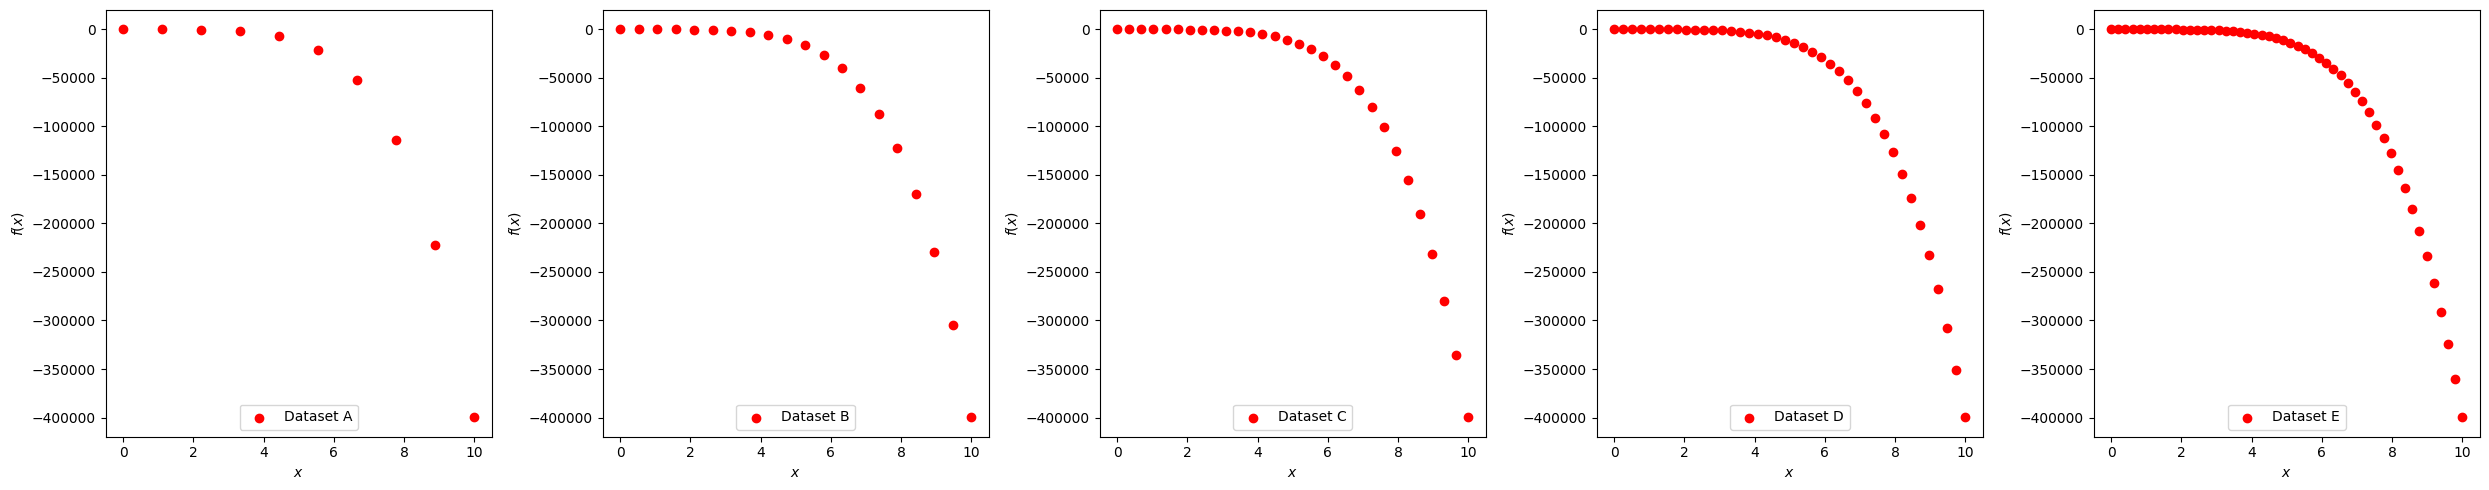

In [47]:

def genera_dataset_funzione(func, lunghezze):
    x_arr = []
    f_arr = []
    names = []
    lettere = string.ascii_uppercase
    for i, n in enumerate(lunghezze):
        x = np.linspace(0, 10, n, dtype=float)
        f = func(x).astype(float)
        x_arr.append(x)
        f_arr.append(f)
        names.append(rf'Dataset {lettere[i % len(lettere)]}')
    return x_arr, f_arr, names

def func(x):
    return 2*x**2 - 4*x**5 + 3*np.cos(x)

x_arr, f_arr, names = genera_dataset_funzione(func, np.linspace(10, 50, 5, dtype=int))

def plot_lag(x, y, name):
    fig, ax = plt.subplots(1, len(x), figsize=(5*len(x), 5))
    ax = np.atleast_1d(ax)
    for i in range(len(x)):
        ax[i].scatter(x[i], y[i], label=name[i], color='red')
        ax[i].set_xlabel(r'$x$')
        ax[i].set_ylabel(r'$f(x)$')
        ax[i].legend(loc='lower center')
    plt.tight_layout()
    plt.savefig('plots_alt/alt_dataset.png', dpi=300)
    plt.show()

plot_lag(x_arr, f_arr, names)


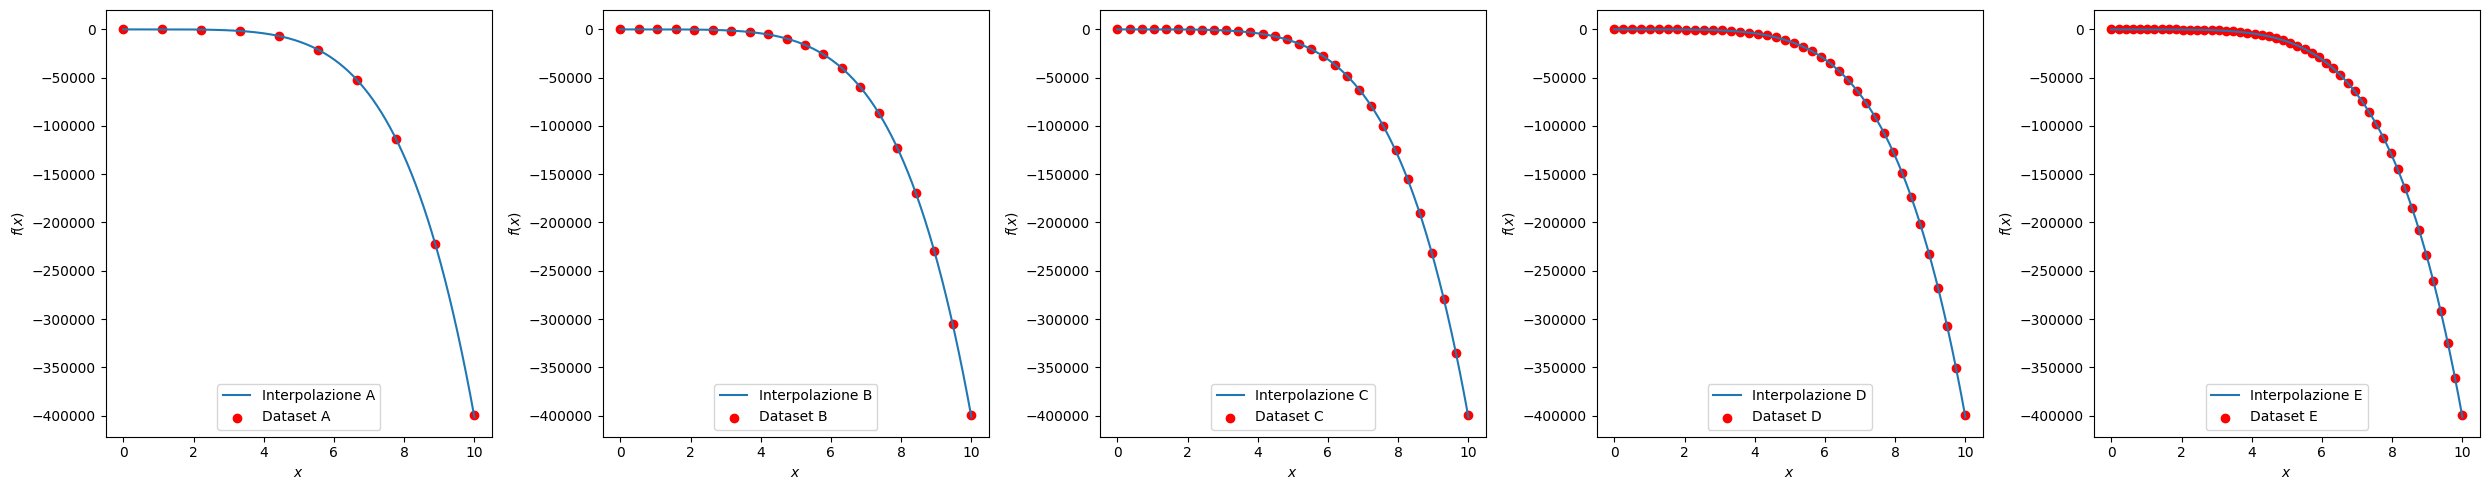

In [48]:

xLag_arr = []
fLag_arr = []
for i in range(len(x_arr)):
    xLag, YLag = lagrange_int(x_arr[i], f_arr[i])
    xLag_arr.append(xLag)
    fLag_arr.append(YLag)

names = [n.replace('Dataset ', '') for n in names]

def plot_lag(x, y, xLag, fLag, name):
    fig, ax = plt.subplots(1, len(x), figsize=(5*len(x), 5))
    ax = np.atleast_1d(ax)
    for i in range(len(x)):
        ax[i].plot(xLag[i], fLag[i], label=r'Interpolazione ' + name[i])
        ax[i].scatter(x[i], y[i], label=r'Dataset ' + name[i], color='red')
        ax[i].set_xlabel(r'$x$')
        ax[i].set_ylabel(r'$f(x)$')
        ax[i].legend(loc='lower center')
    plt.tight_layout()
    plt.savefig('plots_alt/alt_interp.png', dpi=300)
    plt.show()

plot_lag(x_arr, f_arr, xLag_arr, fLag_arr, names)


c:\Users\Marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


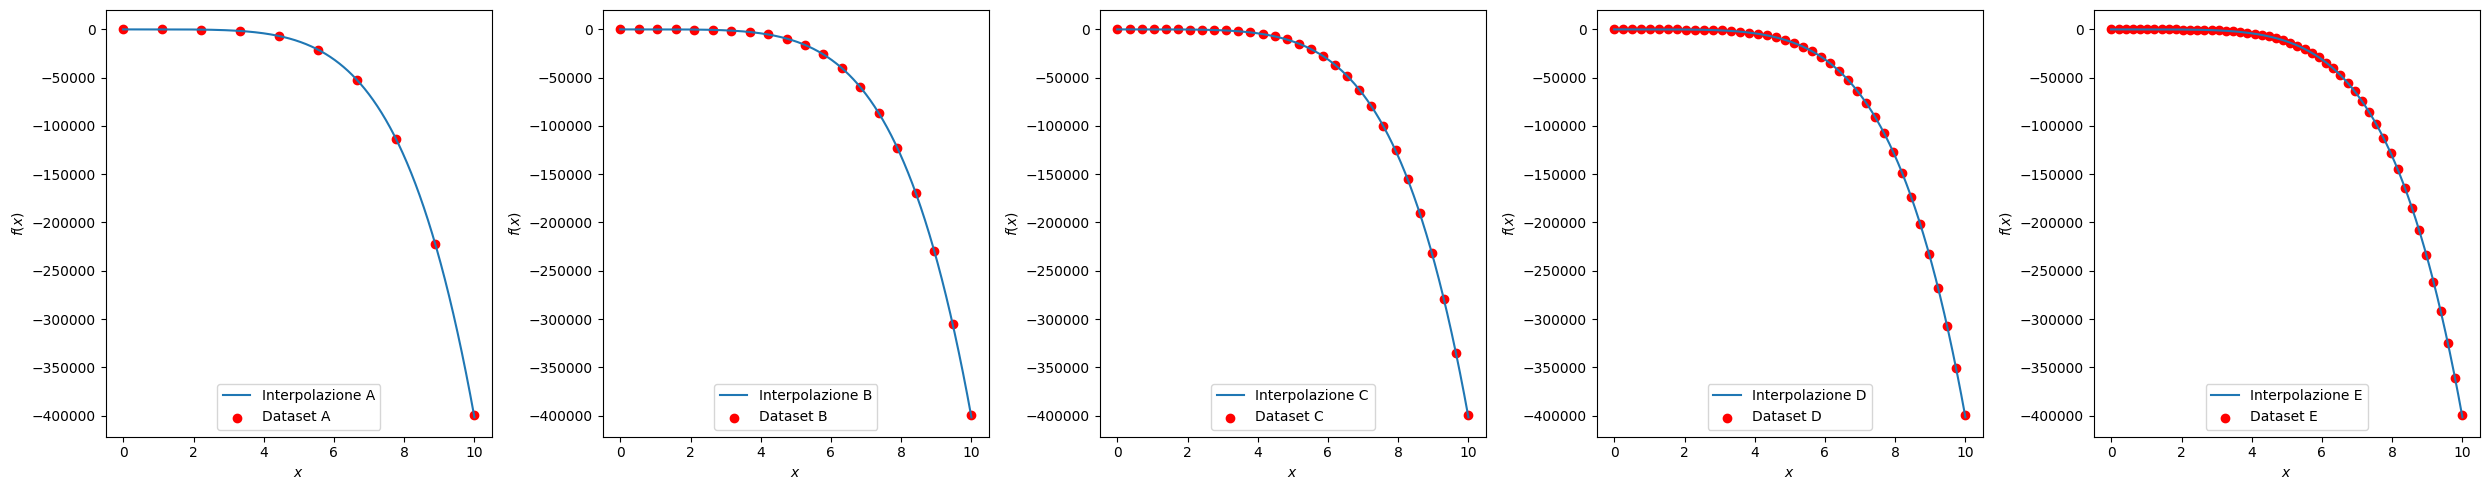

In [49]:

# TENTATIVO CON DIRECT METHOD

from lib_fitting import Direct_mth

def plot_direct(x, y, xLag, fLag, name):
    fig, ax = plt.subplots(1, len(x), figsize=(5*len(x), 5))
    ax = np.atleast_1d(ax)
    for i in range(len(x)):
        ax[i].plot(xLag[i], fLag[i], label=r'Interpolazione ' + name[i])
        ax[i].scatter(x[i], y[i], label=r'Dataset ' + name[i], color='red')
        ax[i].set_xlabel(r'$x$')
        ax[i].set_ylabel(r'$f(x)$')
        ax[i].legend(loc='lower center')
    plt.tight_layout()
    plt.savefig('plots_alt/alt_direct.png', dpi=300)
    plt.show()

xDir_arr = []
fDir_arr = []
for i in range(len(x_arr)):
    xDir, YDir = Direct_mth(x_arr[i], f_arr[i])
    xDir_arr.append(xDir)
    fDir_arr.append(YDir)

plot_direct(x_arr, f_arr, xDir_arr, fDir_arr, names)

# diff = []
# for i in range(len(fDir_arr)):
#     diff.append(np.abs(np.sum(np.array(fDir_arr[i]) - np.array(fLag_arr[i]))))
#     print(f'diff_{i} =', diff[-1])


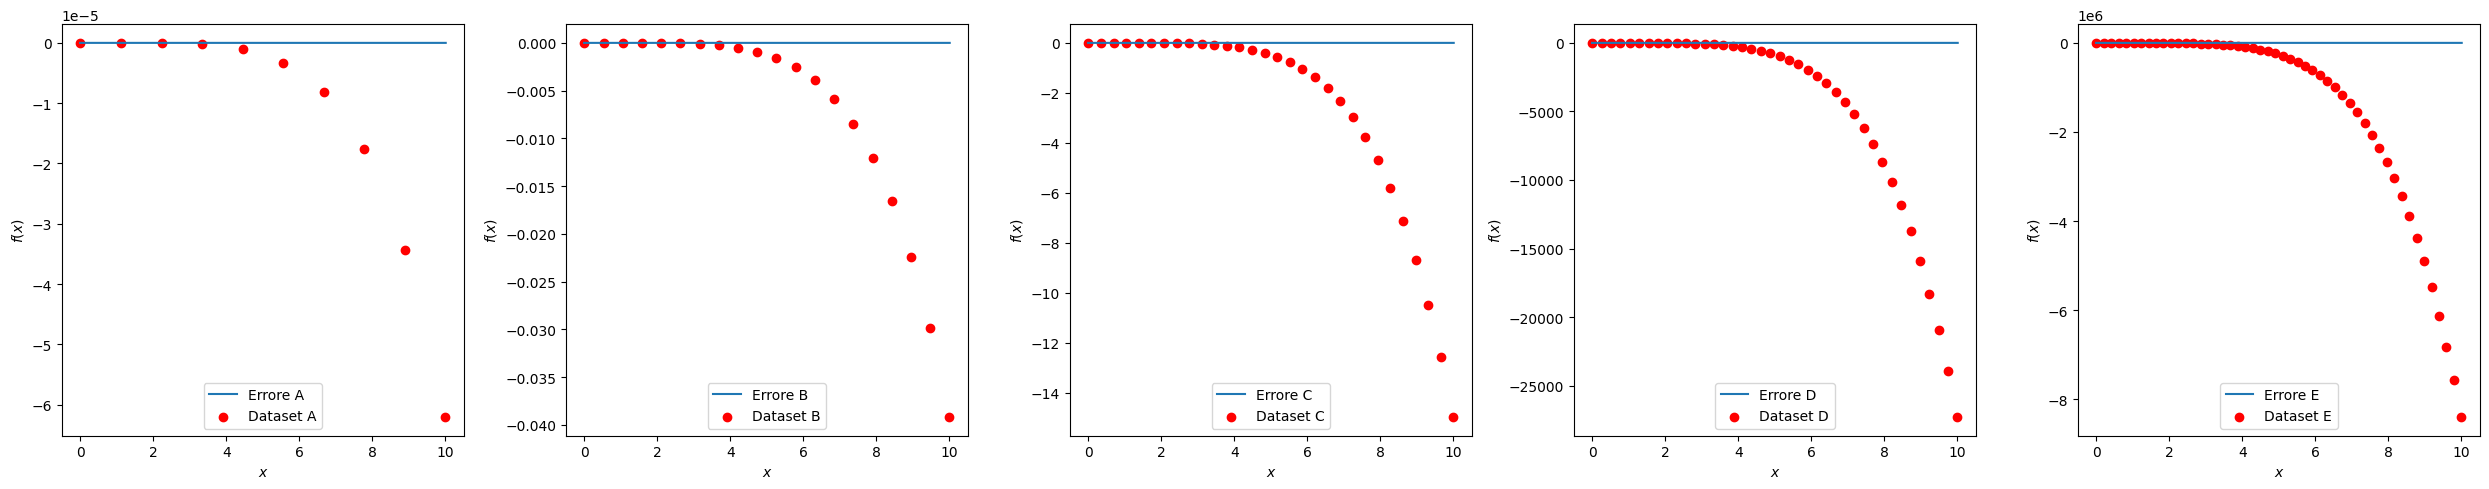

In [50]:

fig, ax = plt.subplots(1, len(fDir_arr), figsize=(5*len(fDir_arr), 5))
ax = np.atleast_1d(ax)
for i in range(len(fDir_arr)):
    res = np.abs(np.array(fDir_arr[i]) - np.array(fLag_arr[i]))
    ax[i].plot(xDir_arr[i], res, label=r'Errore ' + names[i])
    # ax[i].plot(xLag_arr[i], fLag_arr[i]/max(fLag_arr[i]) * max(res), label=r'Interpolazione ' + names[i])
    ax[i].scatter(x_arr[i], f_arr[i]/max(f_arr[i]) * max(res), label=r'Dataset ' + names[i], color='red')
    ax[i].set_xlabel(r'$x$')
    ax[i].set_ylabel(r'$f(x)$')
    # ax[i].set_yscale('log')
    ax[i].legend(loc='lower center')
plt.tight_layout()
plt.savefig('plots_alt/alt_err.png', dpi=300)
plt.show()